# Crypto Fortune Analysis: A Data Visualization Journey

---

## 📖 The Story

Meet Sarah, Marcus, and Elena - three friends who invested in cryptocurrency back in 2020. They each chose different strategies and coins. Now, in 2025, they want to analyze their investment performance and understand which approach worked best.

This notebook will help us visualize their journey using Python's powerful visualization libraries: **Matplotlib** and **Seaborn**.

---

## 📦 Step 1: Import Required Libraries

Before we begin our analysis, we need to import the tools we'll use:
- **pandas**: For organizing our data in tables (DataFrames)
- **matplotlib.pyplot**: The foundational plotting library in Python
- **seaborn**: Built on matplotlib, provides beautiful statistical visualizations
- **numpy**: For numerical operations and calculations

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set the visual style for our plots - 'whitegrid' gives us a clean, professional look
sns.set_style("whitegrid")

# Ensure plots appear in the notebook
%matplotlib inline

print("✓ Libraries loaded successfully!")

✓ Libraries loaded successfully!


## 📊 Step 2: Create Our Cryptocurrency Dataset

We'll create a **dictionary** containing our friends' investment data. Each person invested $5,000 initially in different cryptocurrencies.

The dictionary structure allows us to organize related data together:
- **Keys**: represent the data categories (names, coins, strategies, etc.)
- **Values**: lists containing the actual data for each friend

In [2]:
crypto_investors = {
    'Name': ['Sarah', 'Marcus', 'Elena'],
    'Cryptocurrency': ['Bitcoin', 'Ethereum', 'Diverse Portfolio'],
    'Initial Investment ($)': [5000, 5000, 5000],
    'Current Value ($)': [18500, 15200, 12800],
    'Strategy': ['HODL', 'Active Trading', 'Dollar-Cost Averaging'],
    'Risk Tolerance': ['Medium', 'High', 'Low']
}

# Convert dictionary to a pandas DataFrame for easier manipulation and analysis
df_investors = pd.DataFrame(crypto_investors)

# Display our dataset
print("Our Crypto Investors:")
print("=" * 60)
display(df_investors)

# Calculate returns for each investor
df_investors['Return ($)'] = df_investors['Current Value ($)'] - df_investors['Initial Investment ($)']
df_investors['Return (%)'] = (df_investors['Return ($)'] / df_investors['Initial Investment ($)']) * 100

print("\n💰 With Calculated Returns:")
print("=" * 60)
display(df_investors)

Our Crypto Investors:


,Name,Cryptocurrency,Initial Investment ($),Current Value ($),Strategy,Risk Tolerance
0,Sarah,Bitcoin,5000,18500,HODL,Medium
1,Marcus,Ethereum,5000,15200,Active Trading,High
2,Elena,Diverse Portfolio,5000,12800,Dollar-Cost Averaging,Low



💰 With Calculated Returns:


,Name,Cryptocurrency,Initial Investment ($),Current Value ($),Strategy,Risk Tolerance,Return ($),Return (%)
0,Sarah,Bitcoin,5000,18500,HODL,Medium,13500,270.0
1,Marcus,Ethereum,5000,15200,Active Trading,High,10200,204.0
2,Elena,Diverse Portfolio,5000,12800,Dollar-Cost Averaging,Low,7800,156.0


## 📅 Step 3: Monthly Performance Data

To understand the journey over time, we'll create monthly portfolio values. This time-series data will help us see growth patterns and volatility.

In [3]:
monthly_data = {
    'Month': ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'],
    'Sarah (Bitcoin)': [5000, 5800, 6200, 7500, 9200, 11000, 12500, 13800, 15000, 16200, 17500, 18500],
    'Marcus (Ethereum)': [5000, 6500, 8200, 9500, 7800, 9200, 11500, 13000, 12200, 13800, 14500, 15200],
    'Elena (Diverse)': [5000, 5400, 6100, 6800, 7200, 8500, 9200, 10100, 10800, 11500, 12200, 12800]
}

df_monthly = pd.DataFrame(monthly_data)
print("Monthly Portfolio Performance Over 2024:")
display(df_monthly)

Monthly Portfolio Performance Over 2024:


,Month,Sarah (Bitcoin),Marcus (Ethereum),Elena (Diverse)
0,Jan,5000,5000,5000
1,Feb,5800,6500,5400
2,Mar,6200,8200,6100
3,Apr,7500,9500,6800
4,May,9200,7800,7200
5,Jun,11000,9200,8500
6,Jul,12500,11500,9200
7,Aug,13800,13000,10100
8,Sep,15000,12200,10800
9,Oct,16200,13800,11500


## 📊 Visualization 1: Bar Chart - Comparing Final Returns

### 🤔 WHY USE A BAR CHART?
Bar charts are perfect for comparing discrete categories (our three friends). They make it immediately obvious who performed best and by how much.

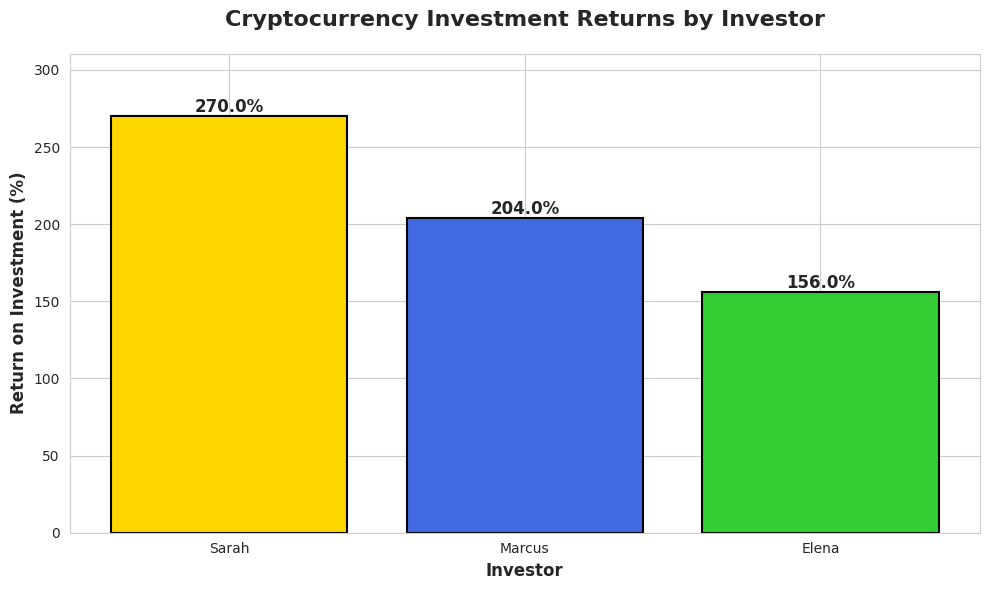

🎯 Key Insight: Sarah's HODL strategy with Bitcoin yielded the highest return!


In [4]:
plt.figure(figsize=(10, 6))

# Create bars with different colors for each investor
colors = ['#FFD700', '#4169E1', '#32CD32']  # Gold, Royal Blue, Lime Green
bars = plt.bar(df_investors['Name'], df_investors['Return (%)'], color=colors, edgecolor='black', linewidth=1.5)

# Add value labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.1f}%',
             ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.title('Cryptocurrency Investment Returns by Investor', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Investor', fontsize=12, fontweight='bold')
plt.ylabel('Return on Investment (%)', fontsize=12, fontweight='bold')
plt.ylim(0, max(df_investors['Return (%)']) * 1.15)  # Add space for labels

plt.tight_layout()
plt.show()

print("🎯 Key Insight: Sarah's HODL strategy with Bitcoin yielded the highest return!")

## 📈 Visualization 2: Line Plot - Portfolio Growth Over Time

### 🤔 WHY USE A LINE PLOT?
Line plots excel at showing trends and changes over time. We can see not just the final outcome, but the journey - including volatility and stability.

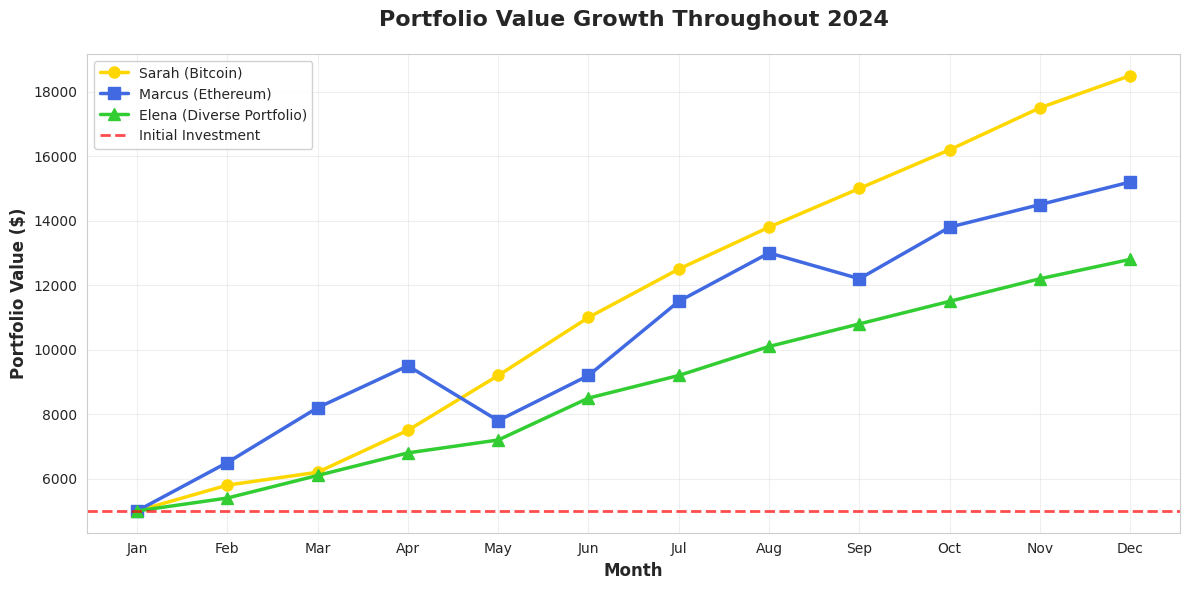

📈 Notice: Marcus experienced more volatility, while Elena had steady growth!


In [5]:
plt.figure(figsize=(12, 6))

# Plot each investor's monthly performance
plt.plot(df_monthly['Month'], df_monthly['Sarah (Bitcoin)'],
         marker='o', linewidth=2.5, markersize=8, label='Sarah (Bitcoin)', color='#FFD700')
plt.plot(df_monthly['Month'], df_monthly['Marcus (Ethereum)'],
         marker='s', linewidth=2.5, markersize=8, label='Marcus (Ethereum)', color='#4169E1')
plt.plot(df_monthly['Month'], df_monthly['Elena (Diverse)'],
         marker='^', linewidth=2.5, markersize=8, label='Elena (Diverse Portfolio)', color='#32CD32')

# Add a horizontal line showing the initial investment
plt.axhline(y=5000, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Initial Investment')

plt.title('Portfolio Value Growth Throughout 2024', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Month', fontsize=12, fontweight='bold')
plt.ylabel('Portfolio Value ($)', fontsize=12, fontweight='bold')
plt.legend(loc='upper left', fontsize=10, framealpha=0.9)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("📈 Notice: Marcus experienced more volatility, while Elena had steady growth!")

## 🥧 Visualization 3: Pie Chart - Investment Strategy Distribution

### 🤔 WHY USE A PIE CHART?
Pie charts show parts of a whole - perfect for showing how total investment value is distributed among our three investors at the end of the year.

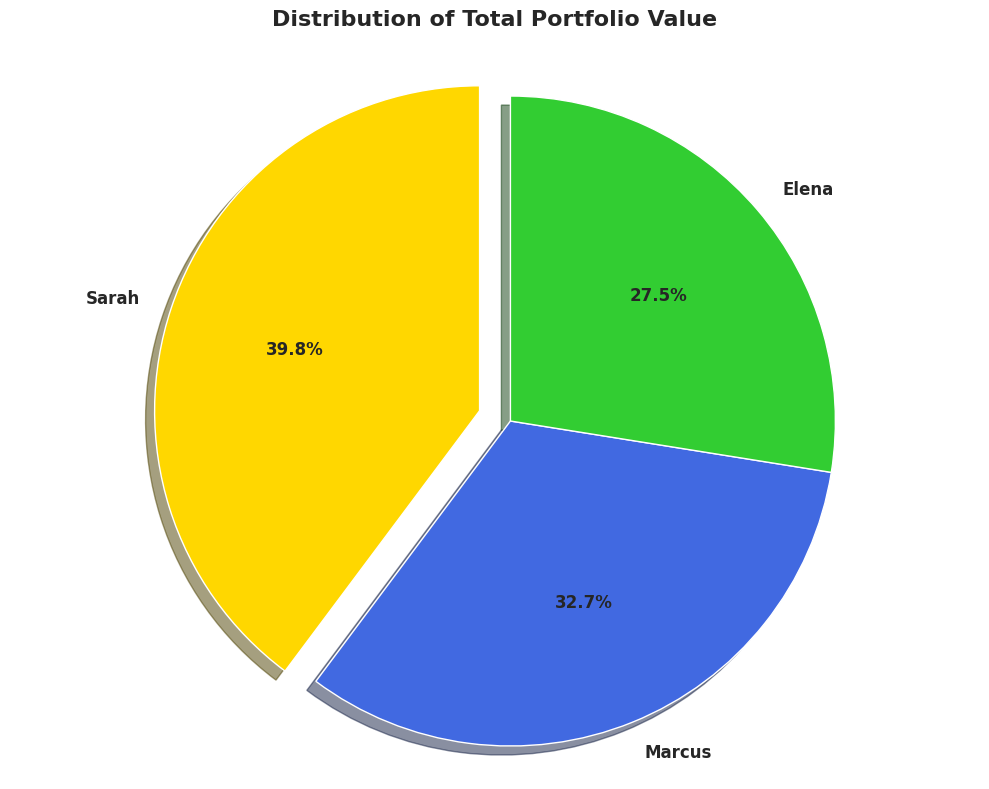

💵 Combined Portfolio Value: $46,500.00
💰 Total Profit: $31,500.00


In [6]:
plt.figure(figsize=(10, 8))

# Calculate final portfolio values and create pie chart
final_values = df_investors['Current Value ($)']
explode = (0.1, 0, 0)  # "Explode" the largest slice (Sarah)

plt.pie(final_values, labels=df_investors['Name'], autopct='%1.1f%%',
        startangle=90, colors=colors, explode=explode,
        textprops={'fontsize': 12, 'fontweight': 'bold'},
        shadow=True)

plt.title('Distribution of Total Portfolio Value', fontsize=16, fontweight='bold', pad=20)
plt.axis('equal')  # Equal aspect ratio ensures pie is circular

plt.tight_layout()
plt.show()

total_value = final_values.sum()
print(f"💵 Combined Portfolio Value: ${total_value:,.2f}")
print(f"💰 Total Profit: ${total_value - 15000:,.2f}")

## 🎯 Visualization 4: Scatter Plot - Risk vs. Return Analysis

### 🤔 WHY USE A SCATTER PLOT?
Scatter plots show relationships between two continuous variables. Here we examine if higher risk tolerance correlates with higher returns.

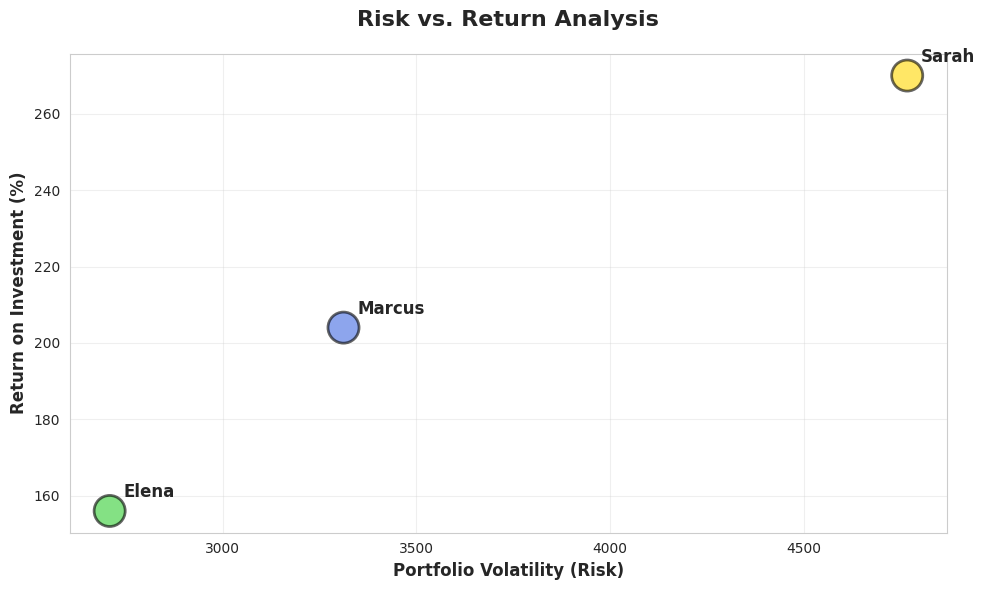

⚠️ Key Insight: Higher volatility (Marcus) doesn't always mean higher returns!


In [7]:
# Calculate volatility (standard deviation of monthly returns) as our risk metric
sarah_volatility = df_monthly['Sarah (Bitcoin)'].std()
marcus_volatility = df_monthly['Marcus (Ethereum)'].std()
elena_volatility = df_monthly['Elena (Diverse)'].std()

risk_return_data = pd.DataFrame({
    'Name': ['Sarah', 'Marcus', 'Elena'],
    'Volatility (Risk)': [sarah_volatility, marcus_volatility, elena_volatility],
    'Return (%)': df_investors['Return (%)'].values
})

plt.figure(figsize=(10, 6))

# Create scatter plot with different colors and sizes
plt.scatter(risk_return_data['Volatility (Risk)'], risk_return_data['Return (%)'],
           s=500, c=colors, alpha=0.6, edgecolors='black', linewidth=2)

# Add labels for each point
for idx, row in risk_return_data.iterrows():
    plt.annotate(row['Name'],
                (row['Volatility (Risk)'], row['Return (%)']),
                fontsize=12, fontweight='bold',
                xytext=(10, 10), textcoords='offset points')

plt.title('Risk vs. Return Analysis', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Portfolio Volatility (Risk)', fontsize=12, fontweight='bold')
plt.ylabel('Return on Investment (%)', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("⚠️ Key Insight: Higher volatility (Marcus) doesn't always mean higher returns!")

## 🔥 Visualization 5: Heatmap with Seaborn - Correlation Analysis

### 🤔 WHY USE A HEATMAP?
Heatmaps visualize matrix data with colors, making it easy to spot patterns and correlations between multiple variables at once.

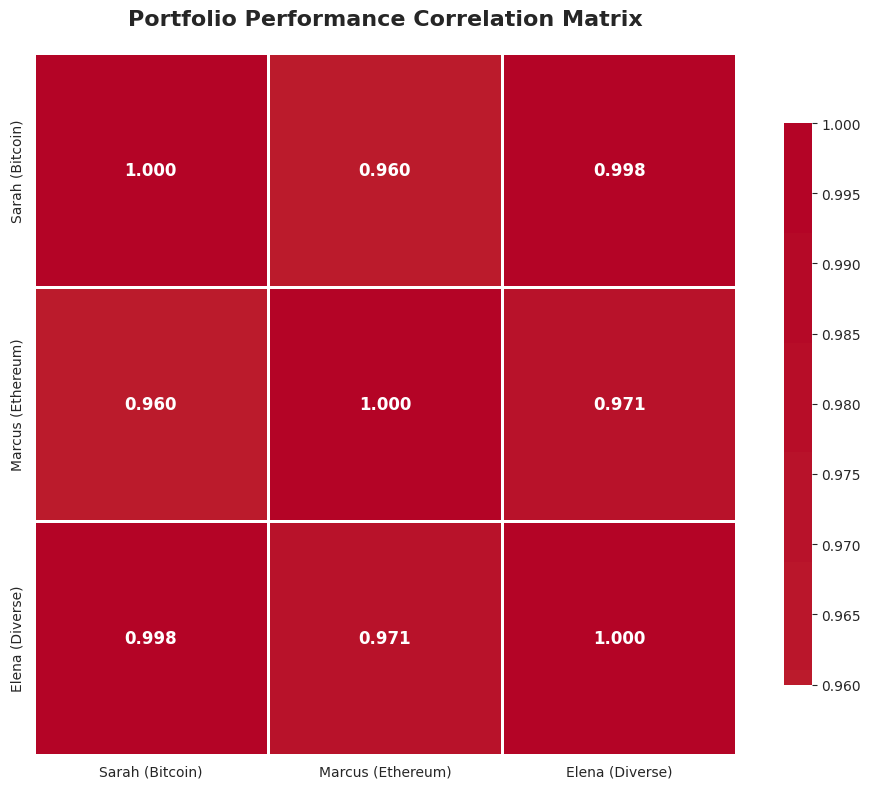

🔗 Correlation shows how similarly different portfolios moved!
1.0 = perfect correlation, 0.0 = no correlation


In [8]:
# Create a correlation matrix from our monthly data
correlation_data = df_monthly[['Sarah (Bitcoin)', 'Marcus (Ethereum)', 'Elena (Diverse)']].corr()

plt.figure(figsize=(10, 8))

# Create heatmap with annotations
sns.heatmap(correlation_data, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=2, cbar_kws={"shrink": 0.8},
            fmt='.3f', annot_kws={'fontsize': 12, 'fontweight': 'bold'})

plt.title('Portfolio Performance Correlation Matrix', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("🔗 Correlation shows how similarly different portfolios moved!")
print("1.0 = perfect correlation, 0.0 = no correlation")

## 📦 Visualization 6: Box Plot with Seaborn - Monthly Return Distribution

### 🤔 WHY USE A BOX PLOT?
Box plots show the distribution of data, including median, quartiles, and outliers. They're excellent for comparing distributions across different categories.

/tmp/ipykernel_7451/2951665982.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=returns_data, x='Investor', y='Monthly Return (%)',


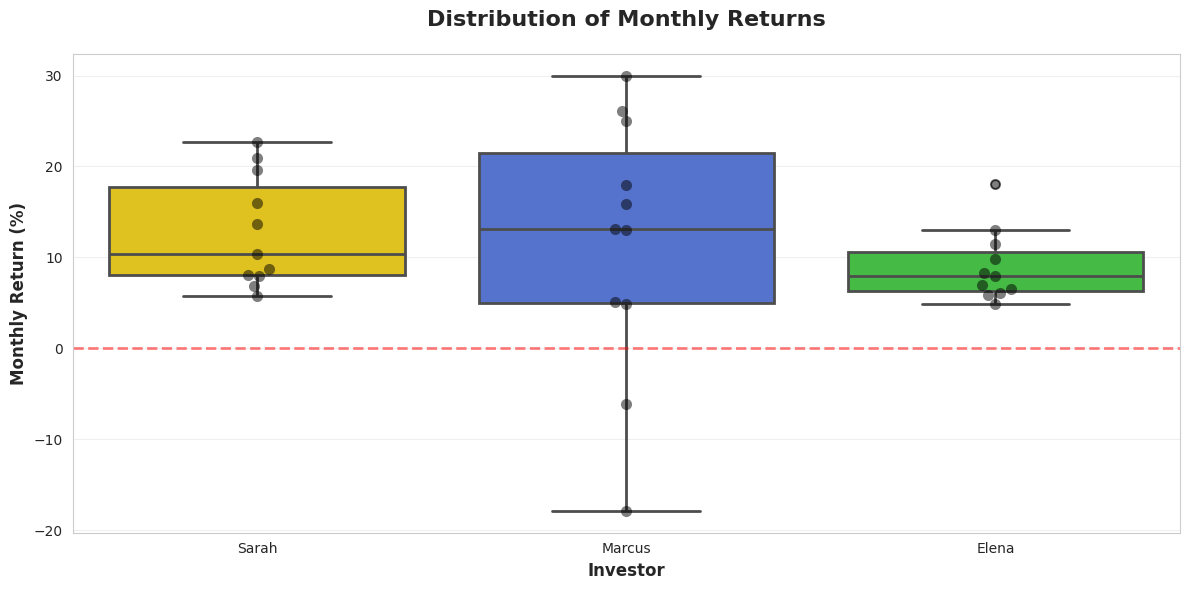

📊 Box plot reveals: Elena had the most consistent returns, Marcus the most variable!


In [9]:
# Calculate monthly returns for each investor
sarah_returns = df_monthly['Sarah (Bitcoin)'].pct_change().dropna() * 100
marcus_returns = df_monthly['Marcus (Ethereum)'].pct_change().dropna() * 100
elena_returns = df_monthly['Elena (Diverse)'].pct_change().dropna() * 100

# Create a DataFrame for box plot
returns_data = pd.DataFrame({
    'Investor': ['Sarah']*len(sarah_returns) + ['Marcus']*len(marcus_returns) + ['Elena']*len(elena_returns),
    'Monthly Return (%)': list(sarah_returns) + list(marcus_returns) + list(elena_returns)
})

plt.figure(figsize=(12, 6))

# Create box plot
sns.boxplot(data=returns_data, x='Investor', y='Monthly Return (%)',
            palette=colors, linewidth=2)

# Add individual points to show all data
sns.swarmplot(data=returns_data, x='Investor', y='Monthly Return (%)',
              color='black', alpha=0.5, size=8)

plt.title('Distribution of Monthly Returns', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Investor', fontsize=12, fontweight='bold')
plt.ylabel('Monthly Return (%)', fontsize=12, fontweight='bold')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2, alpha=0.5)
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("📊 Box plot reveals: Elena had the most consistent returns, Marcus the most variable!")

## 📊 Visualization 7: Grouped Bar Chart - Strategy Comparison

### 🤔 WHY USE A GROUPED BAR CHART?
When comparing multiple metrics across categories, grouped bars make it easy to see both within-category and between-category differences.

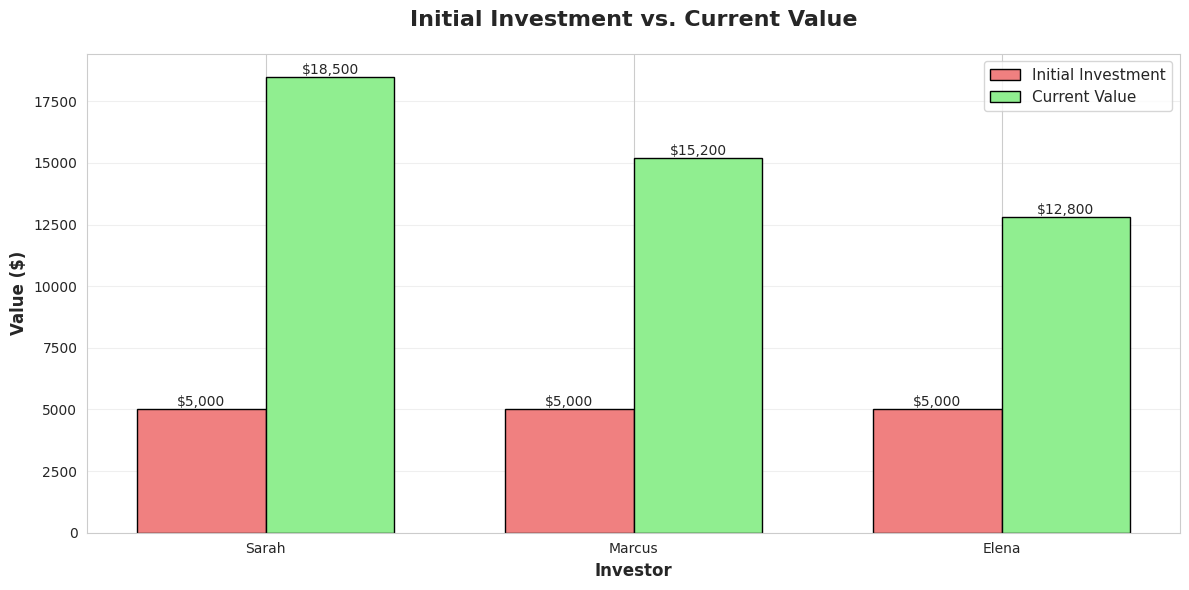

💡 Visual comparison shows the magnitude of each investor's growth!


In [10]:
plt.figure(figsize=(12, 6))

x = np.arange(len(df_investors['Name']))
width = 0.35

# Create bars for initial and current values
bars1 = plt.bar(x - width/2, df_investors['Initial Investment ($)'],
                width, label='Initial Investment', color='lightcoral', edgecolor='black')
bars2 = plt.bar(x + width/2, df_investors['Current Value ($)'],
                width, label='Current Value', color='lightgreen', edgecolor='black')

plt.xlabel('Investor', fontsize=12, fontweight='bold')
plt.ylabel('Value ($)', fontsize=12, fontweight='bold')
plt.title('Initial Investment vs. Current Value', fontsize=16, fontweight='bold', pad=20)
plt.xticks(x, df_investors['Name'])
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'${height:,.0f}',
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

print("💡 Visual comparison shows the magnitude of each investor's growth!")

## 🌊 Visualization 8: Area Chart - Cumulative Gains

### 🤔 WHY USE AN AREA CHART?
Area charts emphasize magnitude and are perfect for showing cumulative totals or the "volume" of change over time.

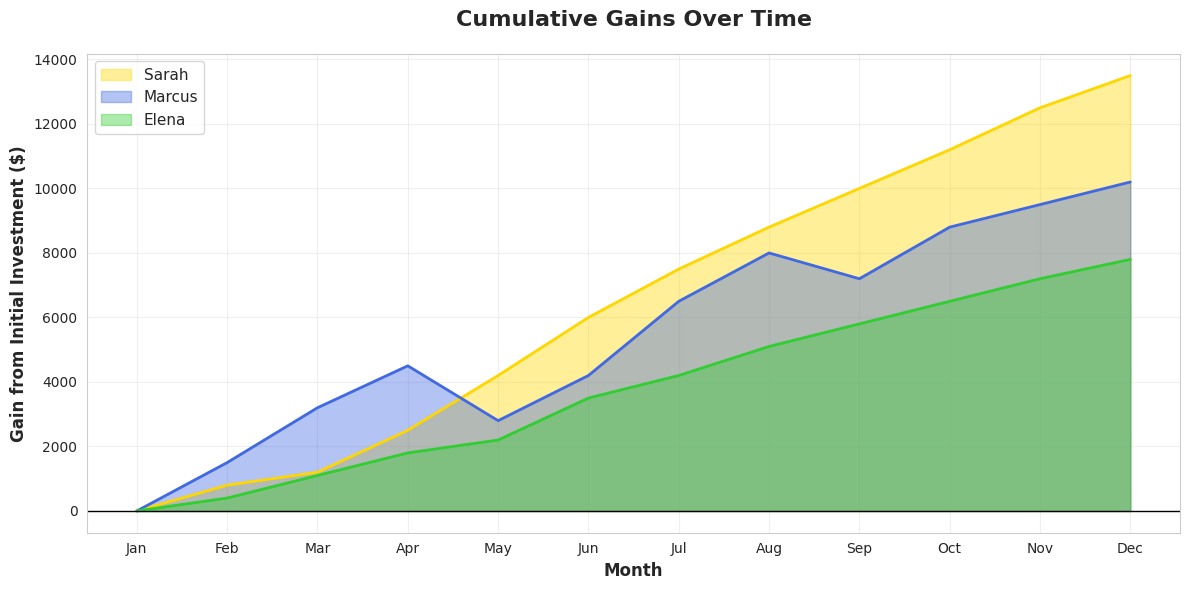

📈 The area under each curve represents total accumulated wealth!


In [11]:
plt.figure(figsize=(12, 6))

# Calculate gains from initial investment
sarah_gains = df_monthly['Sarah (Bitcoin)'] - 5000
marcus_gains = df_monthly['Marcus (Ethereum)'] - 5000
elena_gains = df_monthly['Elena (Diverse)'] - 5000

# Create stacked area chart
plt.fill_between(range(len(df_monthly)), 0, sarah_gains,
                 alpha=0.4, color=colors[0], label='Sarah')
plt.fill_between(range(len(df_monthly)), 0, marcus_gains,
                 alpha=0.4, color=colors[1], label='Marcus')
plt.fill_between(range(len(df_monthly)), 0, elena_gains,
                 alpha=0.4, color=colors[2], label='Elena')

plt.plot(range(len(df_monthly)), sarah_gains, color=colors[0], linewidth=2)
plt.plot(range(len(df_monthly)), marcus_gains, color=colors[1], linewidth=2)
plt.plot(range(len(df_monthly)), elena_gains, color=colors[2], linewidth=2)

plt.title('Cumulative Gains Over Time', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Month', fontsize=12, fontweight='bold')
plt.ylabel('Gain from Initial Investment ($)', fontsize=12, fontweight='bold')
plt.xticks(range(len(df_monthly)), df_monthly['Month'])
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='black', linewidth=1)

plt.tight_layout()
plt.show()

print("📈 The area under each curve represents total accumulated wealth!")

---

## 🎓 Final Summary and Conclusions

### What We Learned About Data Visualization

In [12]:
print("=" * 70)
print("🎓 WHAT WE LEARNED ABOUT DATA VISUALIZATION")
print("=" * 70)
print()
print("📊 Different plot types serve different purposes:")
print()
print("1. BAR CHARTS: Compare discrete categories")
print("   → Best for: Rankings, comparisons, categorical data")
print()
print("2. LINE PLOTS: Show trends over time")
print("   → Best for: Time series, continuous change, trends")
print()
print("3. PIE CHARTS: Display parts of a whole")
print("   → Best for: Proportions, percentages, composition")
print()
print("4. SCATTER PLOTS: Reveal relationships between variables")
print("   → Best for: Correlations, patterns, outliers")
print()
print("5. HEATMAPS: Visualize matrix data with color")
print("   → Best for: Correlations, patterns in 2D data")
print()
print("6. BOX PLOTS: Show distribution and spread")
print("   → Best for: Comparing distributions, finding outliers")
print()
print("7. AREA CHARTS: Emphasize magnitude over time")
print("   → Best for: Cumulative data, volume, magnitude")
print()
print("=" * 70)
print("💰 THE CRYPTO STORY CONCLUSION")
print("=" * 70)
print()
print(f"🥇 Sarah (Bitcoin HODL): {df_investors.loc[0, 'Return (%)']:.1f}% return")
print(f"🥈 Marcus (Ethereum Trading): {df_investors.loc[1, 'Return (%)']:.1f}% return")
print(f"🥉 Elena (Diverse Portfolio): {df_investors.loc[2, 'Return (%)']:.1f}% return")
print()
print("📚 Key Takeaways:")
print("   • Sometimes the simplest strategy (HODL) works best")
print("   • More trading doesn't always mean more profit")
print("   • Diversification provides stability but may limit gains")
print("   • Data visualization helps us understand complex patterns")
print()
print("=" * 70)
print("🎉 Congratulations! You've mastered essential visualization techniques!")
print("=" * 70)

🎓 WHAT WE LEARNED ABOUT DATA VISUALIZATION

📊 Different plot types serve different purposes:

1. BAR CHARTS: Compare discrete categories
   → Best for: Rankings, comparisons, categorical data

2. LINE PLOTS: Show trends over time
   → Best for: Time series, continuous change, trends

3. PIE CHARTS: Display parts of a whole
   → Best for: Proportions, percentages, composition

4. SCATTER PLOTS: Reveal relationships between variables
   → Best for: Correlations, patterns, outliers

5. HEATMAPS: Visualize matrix data with color
   → Best for: Correlations, patterns in 2D data

6. BOX PLOTS: Show distribution and spread
   → Best for: Comparing distributions, finding outliers

7. AREA CHARTS: Emphasize magnitude over time
   → Best for: Cumulative data, volume, magnitude

💰 THE CRYPTO STORY CONCLUSION

🥇 Sarah (Bitcoin HODL): 270.0% return
🥈 Marcus (Ethereum Trading): 204.0% return
🥉 Elena (Diverse Portfolio): 156.0% return

📚 Key Takeaways:
   • Sometimes the simplest strategy (HODL) work